# 🧠 Homework: Language Modeling with N-grams, RNNs, and Attention

**Objective:**  
This assignment introduces students to both classic and neural approaches to language modeling using the WikiText-2 corpus. You will implement:

- A statistical **3-gram model**
- A **neural language model** using LSTM
- An **attention mechanism** for encoder-decoder interactions

⚠️ **Note:**  
Due to the small dataset size and CPU-only runtime constraints, you are **not expected to train models that generate fluent or grammatically correct sentences**. Instead, your goal is to build models that perform **better than random baselines**, capturing some underlying patterns in language structure.

This assignment is designed to run efficiently on CPU using a truncated version of WikiText-2.

### Section 0: Loading the data, DO NOT Modify this cell

In [2]:
!pip install datasets --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import Counter, defaultdict
from torch.utils.data import Dataset, DataLoader
import random
import math
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("parquet", data_files={
    "train":      "train-00000-of-00001.parquet",
    "test":       "test-00000-of-00001.parquet",
    "validation": "validation-00000-of-00001.parquet"
})
tokenizer = lambda x: x.lower().split()
train_text = dataset['train']["text"][:3000000]  # Truncate for speed
train_tokens = [token for line in train_text for token in tokenizer(line)]
print(f"Total train tokens: {len(train_tokens)}")
print(f"First 20 tokens: {train_tokens[:20]}")

# Cell 3: Build vocabulary and numericalize
vocab = {word: idx for idx, word in enumerate(set(train_tokens))}
vocab_inv = {idx: word for word, idx in vocab.items()}
numericalized = [vocab[token] for token in train_tokens]
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Total train tokens: 2051910
First 20 tokens: ['=', 'valkyria', 'chronicles', 'iii', '=', 'senjō', 'no', 'valkyria', '3', ':', 'unrecorded', 'chronicles', '(', 'japanese', ':', '戦場のヴァルキュリア3', ',', 'lit', '.', 'valkyria']
Vocab size: 66649


# 🧩 Problem 1: N-gram Language Model (35 Points)

### ✏️ Description:
You will implement a simple trigram language model using Python dictionaries to count co-occurrences of word sequences.

### 🔧 Your Task:
Complete the following:
- `NGramLM.train()` to populate `self.ngram_counts` from the training data.
- `NGramLM.predict()` to return the most likely next token from a context.

You’ll also use the model to **generate new sequences**.


In [4]:
# Define a simple N-gram Language Model
class NGramLM:
    def __init__(self, n):
        """
        Args:
            n: size of the n-gram (e.g., 3 for trigram model)
        """
        self.n = n
        # Store n-gram frequency counts: {(w1, w2): {w3: count, ...}, ...}
        self.ngram_counts = defaultdict(Counter)

    def train(self, tokens):
        """
        Build n-gram counts from a list of token indices.
        
        Args:
            tokens: list of integer token IDs (numericalized text)
        """
        # TODO:
        # Loop through the tokens, building context and target for each n-gram
        # Get the (n-1)-gram context (e.g., for trigram: (w1, w2))
        # The next word that follows the context (e.g., w3)
        # Count how often each target follows each context
        for i in range(len(tokens) - self.n + 1): 
            target = tokens[i + self.n - 1]
            context = tuple(tokens[i:i + self.n - 1])
            self.ngram_counts[context][target] += 1
        

    def predict(self, context):
        """
        Predict the most likely next token given a context.
        
        Args:
            context: tuple of length (n-1), previous tokens
        Returns:
            Predicted token ID (int)
        """
        # TODO:
        # If we’ve seen this context before, return the most frequent next word
        # If context is unknown, return a random word from the vocab
        if context in self.ngram_counts:
            return self.ngram_counts[context].most_common(1)[0][0]
        else:
            all_tokens = []
    
            for counter in self.ngram_counts.values():
                all_tokens.extend(counter.keys())
    
            return random.choice(all_tokens)


# Instantiate and train a trigram model
ngram_model = NGramLM(n=3)                    # Trigram model (uses 2-word context)
ngram_model.train(numericalized)              # Train on the full token sequence


# -----------------------------------
# Evaluation: Predict next word accuracy
# -----------------------------------
correct = 0
samples = 1000

# Loop through some test samples and measure accuracy
for i in range(samples):
    if i + 2 >= len(numericalized): break

    # Build context and actual next token
    context = tuple(numericalized[i:i+2])     # 2-word context for trigram
    target = numericalized[i+2]               # True next token
    pred = ngram_model.predict(context)       # Model prediction

    if pred == target:
        correct += 1

# Print accuracy over sampled predictions
print(f"n-gram accuracy over {samples} samples: {correct/samples:.2f}")

n-gram accuracy over 1000 samples: 0.59


### ✅ Evaluation DO NOT Modify the cell content:
- The provided accuracy metric checks how often your predicted token matches the actual token.
- Use `generate_ngram_text()` to visually inspect generated samples.

In [5]:
def generate_ngram_text(model, start_text, max_len=20):
    tokens = [vocab.get(w, random.randint(0, vocab_size - 1)) for w in tokenizer(start_text)]
    if len(tokens) < model.n - 1:
        tokens = [random.randint(0, vocab_size - 1) for _ in range(model.n - 1)]

    generated = tokens[:]
    for _ in range(max_len):
        context = tuple(generated[-(model.n - 1):])
        next_token = model.predict(context)
        generated.append(next_token)

    return " ".join(vocab_inv[tok] for tok in generated)

# 🧪 Try generating text with N-gram
print(generate_ngram_text(ngram_model, "the meaning of life is ", max_len=20))

the meaning of life is worth living , it was the first time in the united states , and the other hand , the first



## 🧩 Problem 2: LSTM-based Language Model (35 Points) 

### ✏️ Description:
Implement and train a small LSTM language model using PyTorch. The model takes a sequence of word indices as input and predicts the next token at each time step.

### 🔧 Your Task:
- Replace the `RNN` with `nn.LSTM` in the `LSTMLM` model.
- Implement the `forward()` function to return vocabulary logits at each time step.
- Use `train_rnn()` to train your model.

In [16]:
# Define a PyTorch Dataset for Language Modeling
class LanguageDataset(Dataset):
    def __init__(self, data, seq_len):
        """
        Args:
            data: a list of numericalized tokens (integers)
            seq_len: number of tokens per input sequence
        """
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        # Number of sequences we can extract from the data
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        """
        Returns a tuple (input_seq, target_seq) where:
        - input_seq: tokens from idx to idx+seq_len
        - target_seq: the next seq_len tokens (shifted by 1)
        Both are torch tensors.
        """
        return (
            torch.tensor(self.data[idx:idx+self.seq_len]),         # input: e.g. [the, cat, sat]
            torch.tensor(self.data[idx+1:idx+self.seq_len+1])      # target: e.g. [cat, sat, on]
        )

# Define dataset parameters
seq_len = 20                 # number of tokens per training example
batch_size = 16              # how many sequences per batch
dataset = LanguageDataset(numericalized, seq_len)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


# Define an LSTM-based Language Model
class LSTMLM(nn.Module):
    def __init__(self, vocab_size, embed_size=32, hidden_size=64):
        """
        Args:
            vocab_size: total number of unique tokens
            embed_size: dimension of word embeddings
            hidden_size: dimension of hidden states in the LSTM
        """
        super().__init__()
        # Embedding layer: maps token index to dense vector
        self.embed = nn.Embedding(vocab_size, embed_size)

        # LSTM layer: takes a sequence of embeddings and outputs hidden states
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

        # Fully connected layer: projects LSTM output to vocabulary size
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len) of token IDs
        Returns:
            logits: (batch_size, seq_len, vocab_size) – raw scores before softmax
        """
        #TODO Implement the forward pass of the LSTM
        embedd = self.embed(x)
        output, (hidden, cell) = self.lstm(embedd)
        logits = self.fc(output)

        return logits

        

# Instantiate model, optimizer, and loss
model = LSTMLM(vocab_size)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()   # This loss expects logits and target indices


# Define a training loop for the language model
def train_rnn(model, dataloader, epochs=20, max_batches=50):
    """
    Args:
        model: LSTM language model
        dataloader: batches of (input, target) sequences
        epochs: number of training passes over the data
        max_batches: limit for quick training
    """
    model.train()  # Set model to training mode

    for epoch in range(epochs):
        total_loss = 0
        # TODO:
        # for i, (x, y) in enumerate(dataloader) do the following
        # Reset gradients
        # Forward pass
        # Flatten for loss
        # Backpropagation
        # Update weights
        # update total loss
        for i, (x, y) in enumerate(dataloader):
            if i > max_batches:
                break
            optimizer.zero_grad()
            logits = model(x)
            logits_flat, y_flat = logits.reshape(-1, vocab_size), y.reshape(-1)
            loss = criterion(logits_flat, y_flat)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss / max_batches:.4f}")

# Start training
train_rnn(model, dataloader)

Epoch 1, Loss: 9.0453
Epoch 2, Loss: 7.8957
Epoch 3, Loss: 7.6228
Epoch 4, Loss: 7.4854
Epoch 5, Loss: 7.3743
Epoch 6, Loss: 7.2851
Epoch 7, Loss: 7.2209
Epoch 8, Loss: 7.1357
Epoch 9, Loss: 7.0609
Epoch 10, Loss: 7.0720
Epoch 11, Loss: 6.9581
Epoch 12, Loss: 6.9373
Epoch 13, Loss: 6.9110
Epoch 14, Loss: 6.8838
Epoch 15, Loss: 6.8871
Epoch 16, Loss: 6.7759
Epoch 17, Loss: 6.8025
Epoch 18, Loss: 6.8064
Epoch 19, Loss: 6.7135
Epoch 20, Loss: 6.7257


### ✅ Evaluation DO NOT Modify the cell content:
- Ensure the training loss decreases over epochs.
- Use `generate_text_no_repeat()` to generate sequences while avoiding repeated tokens.

In [17]:
def generate_text_no_repeat(model, vocab, vocab_inv, start_text="the", max_len=50):
    model.eval()
    with torch.no_grad():
        input_ids = [vocab.get(token, 0) for token in start_text.lower().split()]
        generated = input_ids.copy()
        seen = set(generated)

        for _ in range(max_len):
            input_tensor = torch.tensor([[generated[-1]]])  # (1, 1)
            logits = model(input_tensor)[0, -1, :]  # Get last timestep logits

            # Penalize logits of already generated tokens
            for token_id in seen:
                logits[token_id] -= 1e9  # effectively mask out

            next_token = torch.argmax(logits).item()
            next_word = vocab_inv.get(next_token, "")
            if next_word in [".", "<eos>", "<pad>"]:
                break

            generated.append(next_token)
            seen.add(next_token)

        return " ".join([vocab_inv[idx] for idx in generated])
print(generate_text_no_repeat(model, vocab, vocab_inv, start_text="the meaning of life is", max_len=400))

the meaning of life is a few , and "


### 🧠 Problem 3: Implementing Additive Attention (Bahdanau et al., 2015) (30 Points)

In this problem, you will implement the **additive attention mechanism** described in the paper [*Neural Machine Translation by Jointly Learning to Align and Translate* (Bahdanau et al., 2015)](https://arxiv.org/abs/1409.0473). This approach to attention is also known as *Bahdanau Attention*, and was one of the first attention mechanisms introduced in deep learning-based sequence modeling.

This mechanism allows the decoder to attend to different parts of the source sentence dynamically at each decoding step, improving translation quality for longer sequences.

---

#### 📝 Task:

You will implement a function (or class) that does the following:

- Takes as input:
  - The **decoder hidden state** at time `t` (`s_t`) — shape `(batch_size, 1, hidden_dim)`
  - The **encoder hidden states** (`h_i`) — shape `(batch_size, src_len, hidden_dim)`

- Computes attention scores using an MLP:
  - Use the following scoring function from the paper:
  
    ```
    e_i = vᵗ tanh(W₁ h_i + W₂ s_t)
    ```

- Applies softmax over the scores to obtain **attention weights**

- Computes the **context vector** as a weighted sum of the encoder hidden states

- Returns:
  - The context vector: shape `(batch_size, 1, hidden_dim)`
  - The attention weights: shape `(batch_size, 1, src_len)`

---

#### 🔍 Specification:

- Use `nn.Linear` layers for `W₁` and `W₂`
- Combine the encoder and decoder projections with a `tanh` nonlinearity
- Project to scalar attention scores using a final linear layer with output dim `1`
- Apply `softmax` over the sequence length dimension

---

#### 🧪 Evaluation:

We will simulate:

- A batch of encoder hidden states (e.g., from a 6-token source sentence)
- A decoder hidden state at one time step

You should:

- Run your attention function
- Print the shape of the returned context vector and attention weights
- Visualize the attention weights with a heatmap to verify focus over encoder positions

---

Context vector shape: torch.Size([1, 1, 64])
Attention weights shape: torch.Size([1, 1, 6])


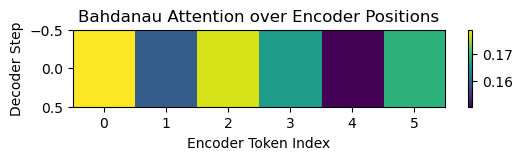

In [28]:
# Simulate dummy encoder outputs (6 source tokens, each with hidden_dim vector)
batch_size = 1
src_len = 6
hidden_dim = 64
encoder_outputs = torch.rand(batch_size, src_len, hidden_dim)
# Simulate current decoder hidden state (one timestep, hence length=1)
decoder_hidden = torch.rand(batch_size, 1, hidden_dim)

# Define the Additive (Bahdanau-style) Attention mechanism as a PyTorch module
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # These linear layers project the query and keys into a shared hidden space
        self.W1 = nn.Linear(hidden_dim, hidden_dim)  # for keys (encoder outputs)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)  # for query (decoder hidden state)
        self.v = nn.Linear(hidden_dim, 1)            # final scoring layer to compute attention score scalar

    def forward(self, query, keys, values):
        """
        query:     decoder hidden state at current time step (batch, 1, hidden_dim)
        keys:      all encoder hidden states (batch, src_len, hidden_dim)
        values:    same as keys; used to compute the weighted context vector
        returns:
            context: weighted sum of encoder outputs (batch, 1, hidden_dim)
            weights: attention weights over encoder tokens (batch, 1, src_len)
        """

        # TODO
        
        # Expand query along the time dimension so it can be added to all keys
        # query shape: (batch, 1, hidden_dim) → (batch, src_len, hidden_dim)
        batch, src_len, hidden_dim = keys.shape
        query_time = query.expand(batch, src_len, hidden_dim)
        

        # Compute energy scores using additive attention formula:
        # energy = tanh(W1(keys) + W2(query))
        # keys:     (batch, src_len, hidden_dim)
        # query:    (batch, src_len, hidden_dim)  ← broadcasted
        # energy:   (batch, src_len, hidden_dim)
        energy = torch.tanh(self.W1(keys) + self.W2(query_time))

        # Compute attention scores:
        # scores: (batch, src_len, 1) → squeeze last dim → (batch, src_len)
        # then unsqueeze to (batch, 1, src_len) so it matches dot attention format
        scores = self.v(energy)
        scores = scores.squeeze(-1) # remove last dim
        scores = scores.unsqueeze(1) # add middle dim
        

        # Apply softmax to convert scores into attention weights over encoder time steps
        # weights: (batch, 1, src_len) — attention distribution over source tokens
        weights = F.softmax(scores, dim=-1)
        

        # Compute the weighted sum of values using attention weights
        # values:  (batch, src_len, hidden_dim)
        # context: (batch, 1, hidden_dim)
        context = torch.bmm(weights, values)
        
        # Return both the context vector and attention weights for visualization/inspection
        return context, weights




# Create an attention module and compute attention
attention = AdditiveAttention(hidden_dim)
context_vector, attention_weights = attention(decoder_hidden, encoder_outputs, encoder_outputs)

# Output dimensions
print("Context vector shape:", context_vector.shape)         # Expected: (1, 1, 64)
print("Attention weights shape:", attention_weights.shape)   # Expected: (1, 1, 6)
# Optional: visualize the attention weights using matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 1))
plt.imshow(attention_weights.squeeze(0).detach().numpy(), cmap="viridis", aspect="auto")
plt.colorbar()
plt.title("Bahdanau Attention over Encoder Positions")
plt.xlabel("Encoder Token Index")
plt.ylabel("Decoder Step")
plt.show()